Run 1/100 complete.
Run 2/100 complete.
Run 3/100 complete.
Run 4/100 complete.
Run 5/100 complete.
Run 6/100 complete.
Run 7/100 complete.
Run 8/100 complete.
Run 9/100 complete.
Run 10/100 complete.
Run 11/100 complete.
Run 12/100 complete.
Run 13/100 complete.
Run 14/100 complete.
Run 15/100 complete.
Run 16/100 complete.
Run 17/100 complete.
Run 18/100 complete.
Run 19/100 complete.
Run 20/100 complete.
Run 21/100 complete.
Run 22/100 complete.
Run 23/100 complete.
Run 24/100 complete.
Run 25/100 complete.
Run 26/100 complete.
Run 27/100 complete.
Run 28/100 complete.
Run 29/100 complete.
Run 30/100 complete.
Run 31/100 complete.
Run 32/100 complete.
Run 33/100 complete.
Run 34/100 complete.
Run 35/100 complete.
Run 36/100 complete.
Run 37/100 complete.
Run 38/100 complete.
Run 39/100 complete.
Run 40/100 complete.
Run 41/100 complete.
Run 42/100 complete.
Run 43/100 complete.
Run 44/100 complete.
Run 45/100 complete.
Run 46/100 complete.
Run 47/100 complete.
Run 48/100 complete.
R

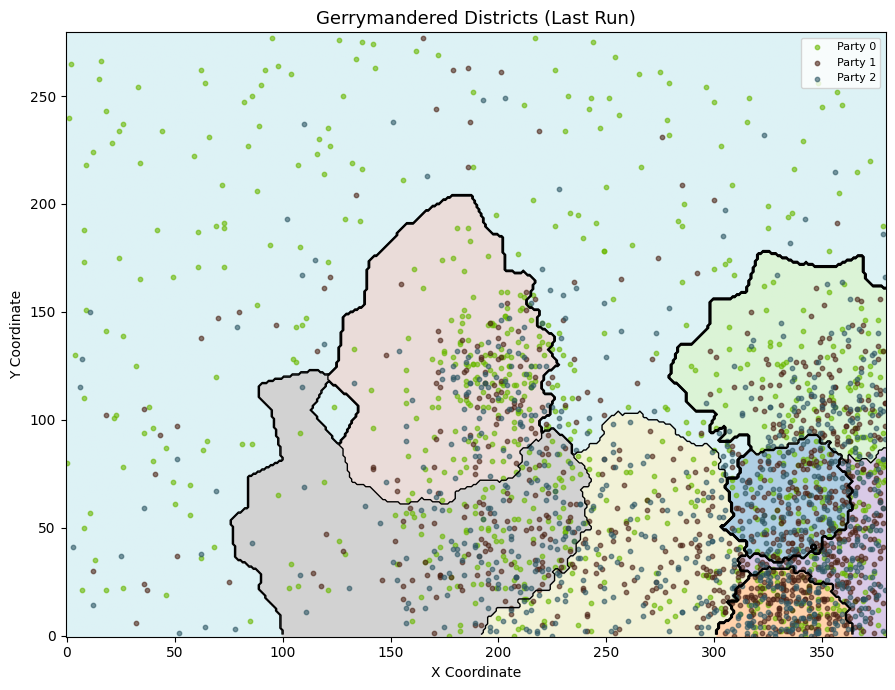

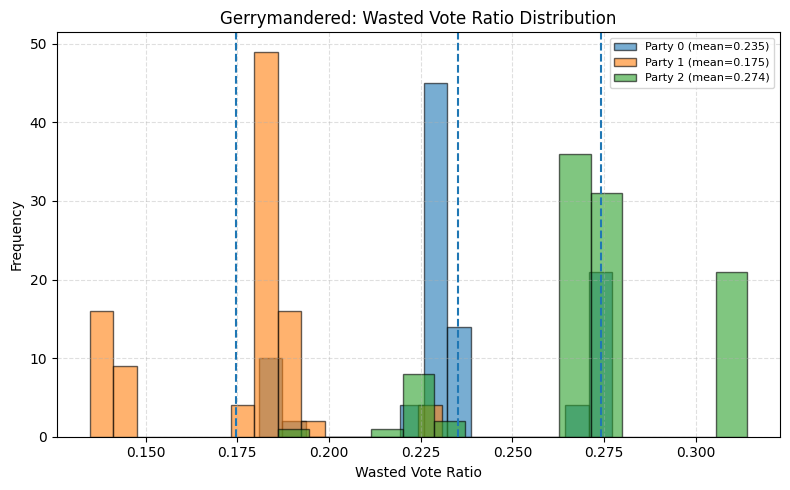

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import itertools
import pandas as pd
import copy 

# ============================================================
# PARAMETERS
# ============================================================
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 2500
NUM_PARTIES = 3
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 100

NUM_CITIES = 6
CITY_INTENSITY = (15, 40)
CITY_SPREAD = (15, 35)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

PARTY_BIAS = [0.45, 0.30, 0.25]

# ============================================================
# GENERATE POPULATION DENSITY
# ============================================================
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ============================================================
# SPATIALLY CORRELATED PARTY PREFERENCES
# ============================================================
party_centers = np.column_stack((
    np.random.uniform(0, WIDTH,  NUM_PARTIES),
    np.random.uniform(0, HEIGHT, NUM_PARTIES)
))

voter_parties = np.zeros(NUM_VOTERS, dtype=int)

for i in range(NUM_VOTERS):
    dists   = np.linalg.norm(party_centers - voters[i], axis=1)
    sigma   = 150
    weights = np.exp(-dists**2 / (2 * sigma**2))
    weights = weights * np.array(PARTY_BIAS)
    weights /= weights.sum()
    voter_parties[i] = np.random.choice(NUM_PARTIES, p=weights)

voter_colors = party_colors[voter_parties]
# ============================================================
# DISTRICT GENERATION — GERRYMANDERED
# ============================================================
def connected_districts_gerrymandered(voters, num_districts, voters_per_district,
                                       rng, target_party, bias_strength=0.75,
                                       k_neighbors=50):
    N = len(voters)
    district = -np.ones(N, dtype=int)
    tree = cKDTree(voters)
    unassigned = set(range(N))

    for d in range(num_districts):
        if not unassigned:
            break

        seed = list(unassigned)[rng.integers(len(unassigned))]
        district[seed] = d
        unassigned.remove(seed)
        queue = [seed]
        count = 1

        while queue and count < voters_per_district:
            current = queue.pop(0)
            _, neighbors = tree.query(voters[current], k=k_neighbors)
            neighbors = list(neighbors)

            def score(n):
                is_target = (voter_parties[n] == target_party)
                return bias_strength * is_target + (1 - bias_strength) * rng.random()

            neighbors = sorted(neighbors, key=score, reverse=True)

            for n in neighbors:
                if n in unassigned:
                    district[n] = d
                    unassigned.remove(n)
                    queue.append(n)
                    count += 1
                    if count >= voters_per_district:
                        break

        if count < voters_per_district:
            for i in range(N):
                if district[i] == d:
                    district[i] = -1
                    unassigned.add(i)
            return connected_districts_gerrymandered(
                voters, num_districts, voters_per_district,
                rng, target_party, bias_strength, k_neighbors
            )

    leftover_indices = np.where(district == -1)[0]
    assigned_indices = np.where(district != -1)[0]

    if len(leftover_indices) > 0:
        assigned_tree = cKDTree(voters[assigned_indices])
        for i in leftover_indices:
            _, idx = assigned_tree.query(voters[i])
            nearest_assigned = assigned_indices[idx]
            district[i] = district[nearest_assigned]
    # ------------------------
    # ENFORCE POPULATION BALANCE (±15%)
    # ------------------------
    min_size = int(voters_per_district * 0.85)
    max_size = int(voters_per_district * 1.15)

    for _ in range(200):
        sizes = np.bincount(district, minlength=num_districts)
        over  = [d for d in range(num_districts) if sizes[d] > max_size]
        under = [d for d in range(num_districts) if sizes[d] < min_size]

        if not over and not under:
            break

        for over_d in over:
            for node in range(N):
                if district[node] != over_d:
                    continue
                if sizes[over_d] <= max_size:
                    break
                # Only move border voters — must touch an underloaded district
                _, neighbors = tree.query(voters[node], k=10)
                for nbr in neighbors:
                    nbr_d = district[nbr]
                    if nbr_d != over_d and sizes[nbr_d] < max_size:
                        district[node]  = nbr_d
                        sizes[over_d]  -= 1
                        sizes[nbr_d]   += 1
                        break

    return district
    

# ============================================================
# VOTE COUNTING
# ============================================================
def count_votes(district_labels):
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts

# ============================================================
# SEAT-VOTE CURVE HELPERS
# ============================================================
def get_is_winner(district_counts, target_party):
    target_votes = district_counts[target_party]
    other_votes = [district_counts[p] for p in district_counts if p != target_party]
    return all(target_votes > v for v in other_votes)

def get_current_vote_share(district_counts, target_party):
    total = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total

def simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            active_competitors = sorted(
                [p for p in competitors if d[p] > 0],
                key=lambda p: (d[p], p)
            )
            if active_competitors:
                from_party = active_competitors[0]
                actual_taken = min(d[from_party], num_competitors)
                if actual_taken > 0:
                    d[from_party] -= actual_taken
                    d[target_party] += actual_taken
                    any_shift = True

        new_wins = count_wins()
        if new_wins > current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins

        if not any_shift or new_wins == NUM_DISTRICTS:
            break

    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}

def simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS):
    counts = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    num_competitors = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            ranked_competitors = sorted(
                competitors,
                key=lambda p: (d[p], p),
                reverse=True
            )
            strongest_competitor = ranked_competitors[0]
            to_move = min(d[target_party], num_competitors)
            if to_move > 0:
                d[target_party] -= to_move
                d[strongest_competitor] += to_move
                any_shift = True

        new_wins = count_wins()
        if new_wins < current_wins:
            vote_share = sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)
            history.append({"districts_won": new_wins, "vote_share": vote_share})
            current_wins = new_wins

        if not any_shift or new_wins == 0:
            break

    return {"history": history, "initial_wins": count_wins(), "initial_vote_share": 0}

def compute_step_curve_for_party(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS):
    initial_vote = get_current_vote_share(district_counts, target_party)
    initial_wins = sum(1 for d in district_counts if get_is_winner(d, target_party))

    fwd = simulate_vote_shifts_forward(district_counts, target_party, PARTY_IDS, NUM_DISTRICTS)
    rev = simulate_vote_shifts_backward(district_counts, target_party, PARTY_IDS)

    base_point = (initial_vote, initial_wins)
    fwd_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in fwd["history"]]
    rev_points = [base_point] + [(h["vote_share"], h["districts_won"]) for h in rev["history"]]

    return sorted(set(fwd_points + rev_points))

def compute_pairwise_area(curve1, curve2, num_districts):
    x1, y1 = zip(*sorted(curve1))
    x2, y2 = zip(*sorted(curve2))

    y1 = np.array(y1) / num_districts
    y2 = np.array(y2) / num_districts

    all_x = np.unique(np.concatenate([x1, x2]))
    if all_x[0] > 0:
        all_x = np.insert(all_x, 0, 0.0)
    if all_x[-1] < 1:
        all_x = np.append(all_x, 1.0)

    def get_val(x, xs, ys):
        idx = np.searchsorted(xs, x, side='right') - 1
        return ys[max(0, idx)]

    total_area = 0.0
    for i in range(len(all_x) - 1):
        mid = (all_x[i] + all_x[i+1]) / 2
        width = all_x[i+1] - all_x[i]
        diff = abs(get_val(mid, x1, y1) - get_val(mid, x2, y2))
        total_area += width * diff

    return total_area

# ============================================================
# VISUALIZATION
# ============================================================
def plot_districts(district_labels, voter_parties, title):
    tree = cKDTree(voters)
    xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
    grid_points = np.column_stack((xx.ravel(), yy.ravel()))
    _, nearest_voter = tree.query(grid_points)
    pixel_map = district_labels[nearest_voter].reshape((HEIGHT, WIDTH))

    plt.figure(figsize=(10, 7))
    plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)
    plt.contour(pixel_map, levels=np.arange(NUM_DISTRICTS) + 0.5,
                colors='black', linewidths=1, origin='lower')
    for i, party in enumerate(PARTY_IDS):
        mask = voter_parties == i
        plt.scatter(voters[mask, 0], voters[mask, 1],
                    color=PARTY_COLORS[party], label=party, s=10, alpha=0.6)
    plt.title(title, fontsize=13)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# ============================================================
# SIMULATION
# ============================================================
all_gerry_counts         = []
all_gerry_pr_vote_shares = []
all_gerry_pr_seat_shares = []
gerry_wasted_vote_table  = []
all_gerry_step_curves    = []
all_gerry_pair_rows      = []

party_pairs = list(itertools.combinations(PARTY_IDS, 2))

for run in range(NUM_RUNS):
    rng_gerry = np.random.default_rng(seed=(run * 7919) + 42)

    gerry_labels = connected_districts_gerrymandered(
        voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT,
        rng_gerry, target_party=1, bias_strength=0.9
    )
    gerry_counts = count_votes(gerry_labels)
    
    all_gerry_counts.append(copy.deepcopy(gerry_counts))

    # ── WASTED VOTES ──────────────────────────────────────
    wasted = {p: 0 for p in PARTY_IDS}
    total  = 0
    for district in gerry_counts:
        dt     = sum(district.values())
        total += dt
        winner = max(district, key=district.get)
        wv     = district[winner]
        nh     = max(v for p, v in district.items() if p != winner)
        excess = wv - (nh + 1)
        for p in PARTY_IDS:
            wasted[p] += excess if p == winner else district[p]
    row = {"Run": run + 1}
    row.update({p: wasted[p] / total for p in PARTY_IDS})
    gerry_wasted_vote_table.append(row)

    # ── PROPORTIONAL REPRESENTATION ───────────────────────
    pr_vote = {p: 0 for p in PARTY_IDS}
    pr_seat = {p: 0 for p in PARTY_IDS}
    for d in gerry_counts:
        for p in PARTY_IDS:
            pr_vote[p] += d[p]
        pr_seat[max(d, key=d.get)] += 1
    total = sum(pr_vote.values())
    for p in PARTY_IDS:
        pr_vote[p] /= total
        pr_seat[p] /= NUM_DISTRICTS
    all_gerry_pr_vote_shares.append(pr_vote)
    all_gerry_pr_seat_shares.append(pr_seat)

    # ── STEP CURVES ───────────────────────────────────────
    gerry_curves = {p: compute_step_curve_for_party(gerry_counts, p, PARTY_IDS, NUM_DISTRICTS) for p in PARTY_IDS}
    all_gerry_step_curves.append(gerry_curves)

    for p1, p2 in party_pairs:
        all_gerry_pair_rows.append({
            "Run": run + 1, "Comparison": f"{p1} vs {p2}",
            "Pairwise_Area": compute_pairwise_area(gerry_curves[p1], gerry_curves[p2], NUM_DISTRICTS)
        })

    print(f"Run {run + 1}/{NUM_RUNS} complete.")

# ============================================================
# RESULTS
# ============================================================
df_gerry = pd.DataFrame(gerry_wasted_vote_table)

print("\n--- GERRYMANDERED: Wasted Vote Ratios ---")
print(df_gerry.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n--- GERRYMANDERED MEAN ---")
print(df_gerry.drop(columns="Run").mean())

df_gerry_pair = pd.DataFrame(all_gerry_pair_rows)
print("\n--- GERRYMANDERED: Pairwise Partisan Symmetry ---")
print(df_gerry_pair.groupby("Comparison")["Pairwise_Area"].agg(["mean", "std"]))

# ============================================================
# VISUALIZE LAST RUN
# ============================================================
plot_districts(gerry_labels, voter_parties, "Gerrymandered Districts (Last Run)")

# ============================================================
# HISTOGRAM: Wasted Vote Ratios
# ============================================================
plt.figure(figsize=(8, 5))
for party in PARTY_IDS:
    mean_val = df_gerry[party].mean()
    plt.hist(df_gerry[party], bins=15, alpha=0.6, edgecolor="black",
             label=f"{party} (mean={mean_val:.3f})")
    plt.axvline(mean_val, linestyle="--", lw=1.5)
plt.title("Gerrymandered: Wasted Vote Ratio Distribution")
plt.xlabel("Wasted Vote Ratio")
plt.ylabel("Frequency")
plt.legend(fontsize=8)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [108]:
# ------------------------
# DISTRICT WINNERS PER RUN
# ------------------------
gerry_winner_rows = []

for run_idx in range(NUM_RUNS):
    gerry_row = {"Run": run_idx + 1}
    for d_idx, gc in enumerate(all_gerry_counts[run_idx]):
        gerry_row[f"District {d_idx + 1}"] = max(gc, key=gc.get)
    gerry_winner_rows.append(gerry_row)

df_gerry_winners = pd.DataFrame(gerry_winner_rows)

print("\n--- GERRYMANDERED MAP: District Winners per Run ---")
print(df_gerry_winners.to_string(index=False))


--- GERRYMANDERED MAP: District Winners per Run ---
 Run District 1 District 2 District 3 District 4 District 5 District 6 District 7 District 8
   1    Party 0    Party 1    Party 0    Party 2    Party 1    Party 0    Party 1    Party 1
   2    Party 1    Party 2    Party 2    Party 0    Party 0    Party 1    Party 1    Party 1
   3    Party 1    Party 0    Party 0    Party 1    Party 0    Party 1    Party 1    Party 0
   4    Party 1    Party 0    Party 1    Party 0    Party 1    Party 1    Party 1    Party 0
   5    Party 1    Party 1    Party 1    Party 0    Party 1    Party 0    Party 1    Party 2
   6    Party 1    Party 0    Party 1    Party 1    Party 1    Party 2    Party 0    Party 0
   7    Party 0    Party 2    Party 0    Party 1    Party 1    Party 1    Party 1    Party 1
   8    Party 1    Party 1    Party 2    Party 1    Party 0    Party 1    Party 0    Party 0
   9    Party 1    Party 0    Party 0    Party 1    Party 1    Party 0    Party 1    Party 1
  10    Party 1  

In [109]:
# ------------------------------------------------------------
# PAIRWISE AREA DIFFERENCES
# ------------------------------------------------------------
df_gerry_pair = pd.DataFrame(all_gerry_pair_rows)

print("\n--- GERRYMANDERED: PAIRWISE AREA DIFFERENCES ---")
print(df_gerry_pair.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\n--- GERRYMANDERED: MEAN BY COMPARISON ---")
print(df_gerry_pair.groupby("Comparison")["Pairwise_Area"].agg(["mean", "std"]))


--- GERRYMANDERED: PAIRWISE AREA DIFFERENCES ---
 Run         Comparison  Pairwise_Area
   1 Party 0 vs Party 1         0.0496
   1 Party 0 vs Party 2         0.0535
   1 Party 1 vs Party 2         0.0430
   2 Party 0 vs Party 1         0.0499
   2 Party 0 vs Party 2         0.0330
   2 Party 1 vs Party 2         0.0425
   3 Party 0 vs Party 1         0.0502
   3 Party 0 vs Party 2         0.0850
   3 Party 1 vs Party 2         0.0545
   4 Party 0 vs Party 1         0.0710
   4 Party 0 vs Party 2         0.0630
   4 Party 1 vs Party 2         0.0597
   5 Party 0 vs Party 1         0.0661
   5 Party 0 vs Party 2         0.0393
   5 Party 1 vs Party 2         0.0507
   6 Party 0 vs Party 1         0.0346
   6 Party 0 vs Party 2         0.0759
   6 Party 1 vs Party 2         0.0603
   7 Party 0 vs Party 1         0.0582
   7 Party 0 vs Party 2         0.0380
   7 Party 1 vs Party 2         0.0422
   8 Party 0 vs Party 1         0.0575
   8 Party 0 vs Party 2         0.0488
   8 Party 1 v

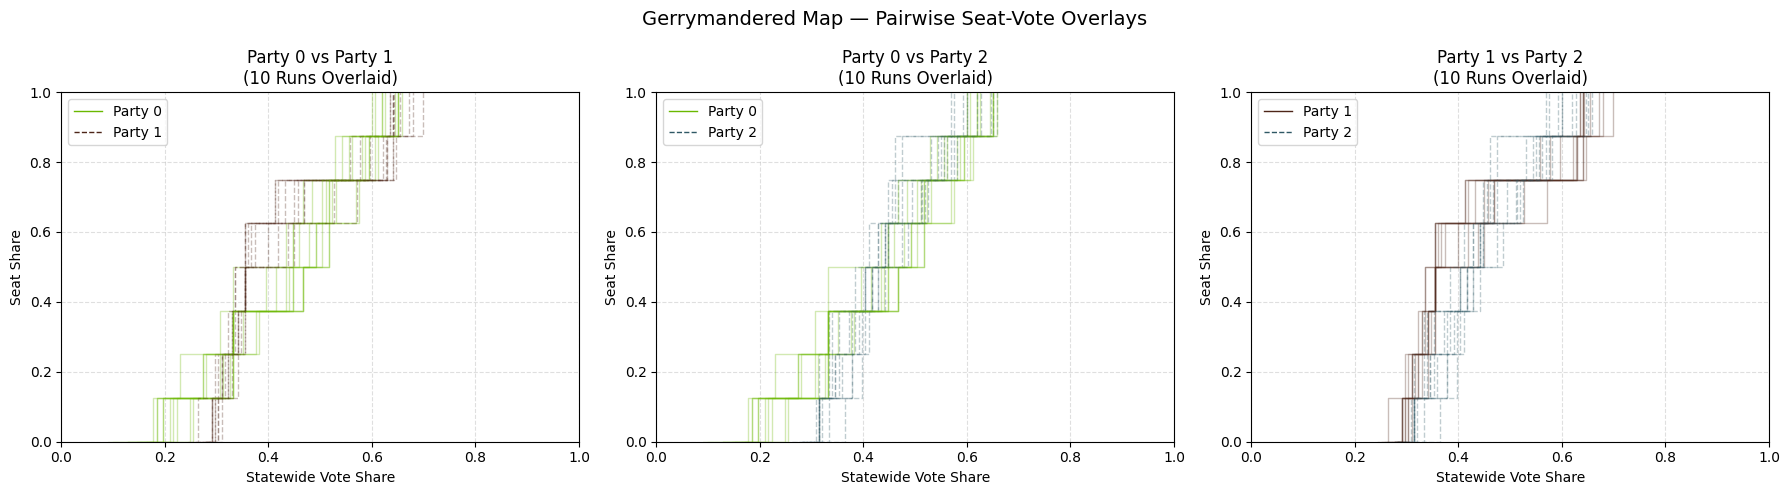

In [110]:
def plot_pairwise_overlays(all_step_curves, title_label, num_runs_to_plot=10):
    party_pairs = list(itertools.combinations(PARTY_IDS, 2))
    num_pairs   = len(party_pairs)

    fig, axes = plt.subplots(1, num_pairs, figsize=(6 * num_pairs, 5), squeeze=False)
    fig.suptitle(title_label, fontsize=14)

    runs_to_show = min(num_runs_to_plot, len(all_step_curves))

    for pair_idx, (party_a, party_b) in enumerate(party_pairs):
        ax = axes[0, pair_idx]

        for run_idx in range(runs_to_show):
            curve_a = all_step_curves[run_idx][party_a]
            curve_b = all_step_curves[run_idx][party_b]

            xa, ya = zip(*sorted(curve_a))
            xb, yb = zip(*sorted(curve_b))

            ya_norm = np.array(ya) / NUM_DISTRICTS
            yb_norm = np.array(yb) / NUM_DISTRICTS

            label_a = party_a if run_idx == 0 else None
            label_b = party_b if run_idx == 0 else None

            ax.step(xa, ya_norm, where='post', color=PARTY_COLORS[party_a],
                    alpha=0.3, lw=1, label=label_a)
            ax.step(xb, yb_norm, where='post', color=PARTY_COLORS[party_b],
                    alpha=0.3, lw=1, label=label_b, linestyle='--')

        ax.set_title(f"{party_a} vs {party_b}\n({runs_to_show} Runs Overlaid)", fontsize=12)
        ax.set_xlabel("Statewide Vote Share")
        ax.set_ylabel("Seat Share")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.4)

        leg = ax.legend(loc='upper left')
        for lh in leg.legend_handles:
            lh.set_alpha(1)

    plt.tight_layout()
    plt.show()

plot_pairwise_overlays(all_gerry_step_curves, "Gerrymandered Map — Pairwise Seat-Vote Overlays")


--- Gerrymandered Map: PAIRWISE AREA DIFFERENCES ---
Run                     1      2      3      4      5      6      7      8      9     10     11     12     13     14     15     16     17     18     19     20     21     22     23     24     25     26     27     28     29     30     31     32     33     34     35     36     37     38     39     40     41     42     43     44     45     46     47     48     49     50     51     52     53     54     55     56     57     58     59     60     61     62     63     64     65     66     67     68     69     70     71     72     73     74     75     76     77     78     79     80     81     82     83     84     85     86     87     88     89     90     91     92     93     94     95     96     97     98     99    100   Mean  Std Dev
Comparison                                                                                                                                                                                                         

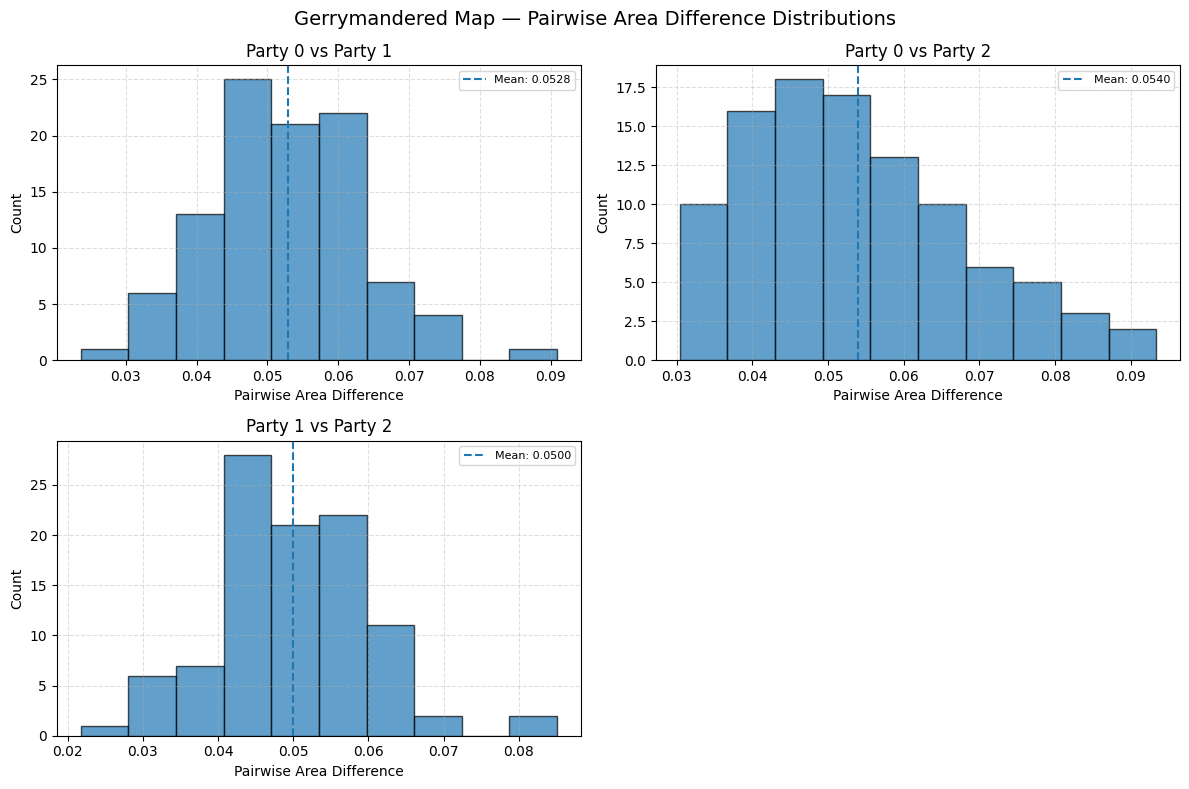

In [111]:
import math

def pairwise_table_and_hist_from_df(df_pair, title_label):

    df_pivot = df_pair.pivot(index="Comparison", columns="Run", values="Pairwise_Area")
    df_pivot["Mean"]    = df_pivot.mean(axis=1)
    df_pivot["Std Dev"] = df_pivot.std(axis=1)

    print(f"\n--- {title_label}: PAIRWISE AREA DIFFERENCES ---")
    print(df_pivot.to_string(float_format=lambda x: f"{x:.4f}"))

    comparisons = df_pivot.index.tolist()
    n_pairs = len(comparisons)
    n_cols  = 2
    n_rows  = math.ceil(n_pairs / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for i, comp in enumerate(comparisons):
        data     = df_pivot.loc[comp].iloc[:len(df_pair["Run"].unique())].values
        mean_val = np.mean(data)

        axes[i].hist(data, bins=min(10, len(data)), alpha=0.7, edgecolor='black')
        axes[i].axvline(mean_val, linestyle='--', linewidth=1.5,
                        label=f"Mean: {mean_val:.4f}")
        axes[i].set_title(comp)
        axes[i].set_xlabel("Pairwise Area Difference")
        axes[i].set_ylabel("Count")
        axes[i].legend(fontsize=8)
        axes[i].grid(True, linestyle="--", alpha=0.4)

    for j in range(len(comparisons), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"{title_label} — Pairwise Area Difference Distributions", fontsize=14)
    plt.tight_layout()
    plt.show()

pairwise_table_and_hist_from_df(df_gerry_pair, "Gerrymandered Map")

In [112]:
def print_election_results(all_district_counts, all_pr_vote_shares,
                           all_pr_seat_shares, label=""):
    for run_idx, district_counts in enumerate(all_district_counts):
        print(f"\n{'='*60}")
        print(f"  {label} RUN {run_idx + 1}")
        print(f"{'='*60}")

        print(f"\n  {'District':<12} {'Winner':<12}", end="")
        for party in PARTY_IDS:
            print(f" {party:>12}", end="")
        print(f" {'Total':>10}")
        print(f"  {'-'*12} {'-'*12}", end="")
        for _ in PARTY_IDS:
            print(f" {'-'*12}", end="")
        print(f" {'-'*10}")

        for d_idx, counts in enumerate(district_counts):
            winner = max(counts, key=counts.get)
            total  = sum(counts.values())
            print(f"  {'District '+str(d_idx+1):<12} {winner:<12}", end="")
            for party in PARTY_IDS:
                print(f" {counts[party]:>12}", end="")
            print(f" {total:>10}")

        seats = {party: 0 for party in PARTY_IDS}
        for counts in district_counts:
            seats[max(counts, key=counts.get)] += 1

        print(f"\n  --- Seats Won ---")
        for party in PARTY_IDS:
            bar = "█" * seats[party]
            print(f"  {party:<12}: {seats[party]:>2} seats  {bar}")

        print(f"\n  --- Statewide Vote Share ---")
        for party in PARTY_IDS:
            vote_share = all_pr_vote_shares[run_idx][party]
            seat_share = all_pr_seat_shares[run_idx][party]
            print(f"  {party:<12}: Vote {vote_share:.3f}  |  Seat Share {seat_share:.3f}")

    print(f"\n{'='*60}")
    print(f"  END OF {label} RESULTS")
    print(f"{'='*60}\n")

print_election_results(all_gerry_counts, all_gerry_pr_vote_shares,
                       all_gerry_pr_seat_shares, label="GERRYMANDERED")


  GERRYMANDERED RUN 1

  District     Winner            Party 0      Party 1      Party 2      Total
  ------------ ------------ ------------ ------------ ------------ ----------
  District 1   Party 0               162           69           81        312
  District 2   Party 1                57          155          100        312
  District 3   Party 0               177           67           68        312
  District 4   Party 2                87          106          119        312
  District 5   Party 1                72          129          111        312
  District 6   Party 0               128           94           90        312
  District 7   Party 1                57          143          113        313
  District 8   Party 1                89          123          103        315

  --- Seats Won ---
  Party 0     :  3 seats  ███
  Party 1     :  4 seats  ████
  Party 2     :  1 seats  █

  --- Statewide Vote Share ---
  Party 0     : Vote 0.332  |  Seat Share 0.375
  Part

In [113]:
def compute_efficiency_gap_table(all_district_counts, label=""):

    gap_rows = []

    for run_idx in range(len(all_district_counts)):
        district_counts = all_district_counts[run_idx]

        wasted_votes = {party: 0 for party in PARTY_IDS}
        total_votes  = 0

        for district in district_counts:
            district_total  = sum(district.values())
            total_votes    += district_total

            sorted_parties  = sorted(district.items(), key=lambda x: x[1], reverse=True)
            winner, _       = sorted_parties[0]
            runner_up_votes = sorted_parties[1][1] if len(sorted_parties) > 1 else 0
            needed_to_win   = runner_up_votes + 1

            for party in PARTY_IDS:
                votes = district[party]
                if party == winner:
                    wasted_votes[party] += max(0, votes - needed_to_win)
                else:
                    wasted_votes[party] += votes

        w = {party: wasted_votes[party] / total_votes for party in PARTY_IDS}

        squared_diff_sum = 0.0
        for p1, p2 in itertools.combinations(PARTY_IDS, 2):
            squared_diff_sum += (w[p1] - w[p2]) ** 2

        gap_rows.append({
            "Run":            run_idx + 1,
            "Efficiency_Gap": squared_diff_sum,
            **{f"{party}_Wasted": w[party] for party in PARTY_IDS}
        })

    df_gap = pd.DataFrame(gap_rows)

    print(f"\n--- {label}: EFFICIENCY GAP ---")
    print(df_gap.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print(f"\nMean Efficiency Gap: {df_gap['Efficiency_Gap'].mean():.4f}")
    print(f"Std  Efficiency Gap: {df_gap['Efficiency_Gap'].std():.4f}")

    return df_gap

df_gerry_gap = compute_efficiency_gap_table(all_gerry_counts, label="GERRYMANDERED")


--- GERRYMANDERED: EFFICIENCY GAP ---
 Run  Efficiency_Gap  Party 0_Wasted  Party 1_Wasted  Party 2_Wasted
   1          0.0120          0.2332          0.1820          0.2712
   2          0.0101          0.2716          0.1896          0.2276
   3          0.0349          0.1844          0.1796          0.3140
   4          0.0454          0.2284          0.1400          0.3140
   5          0.0326          0.2712          0.1456          0.2752
   6          0.0115          0.2316          0.1852          0.2728
   7          0.0331          0.2716          0.1436          0.2728
   8          0.0108          0.2284          0.1860          0.2708
   9          0.0477          0.2332          0.1360          0.3140
  10          0.0092          0.2304          0.1880          0.2664
  11          0.0111          0.2296          0.1844          0.2704
  12          0.0125          0.2292          0.1812          0.2724
  13          0.0349          0.1808          0.1832          0.

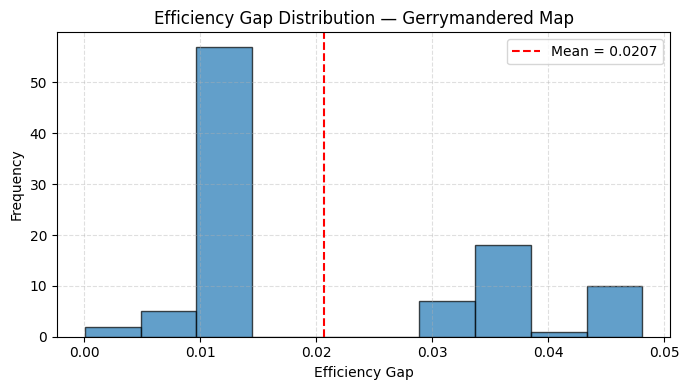

In [114]:
def plot_eg_histogram(df_gap, title="Gerrymandered Map"):
    data     = df_gap["Efficiency_Gap"].values
    mean_val = np.mean(data)

    plt.figure(figsize=(7, 4))
    plt.hist(data, bins=10, alpha=0.7, edgecolor="black")
    plt.axvline(mean_val, color="red", linestyle="--",
                label=f"Mean = {mean_val:.4f}")
    plt.title(f"Efficiency Gap Distribution — {title}")
    plt.xlabel("Efficiency Gap")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_eg_histogram(df_gerry_gap, title="Gerrymandered Map")